In [ ]:
!pip install -q ultralytics opencv-python-headless tensorflow pandas matplotlib tqdm scikit-learn filterpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.8 MB/s eta 0:00:00


In [ ]:
# Simple Python implementation of SORT tracker
import numpy as np
from filterpy.kalman import KalmanFilter

class Sort:
    def __init__(self, max_age=1, min_hits=3, iou_threshold=0.3):
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.trackers = []
        self.frame_count = 0

    def update(self, detections):
        # For simplicity, just return detections directly (dummy tracking for now)
        return detections


In [ ]:
from ultralytics import YOLO
import cv2, numpy as np, pandas as pd, tensorflow as tf
print("YOLOv8 + TensorFlow environment ready!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 + TensorFlow environment ready!


In [ ]:
!pip install ultralytics --upgrade --quiet
import importlib, sys
importlib.reload(sys)

from ultralytics import YOLO
print("Ultralytics YOLOv8 loaded successfully!")


Ultralytics YOLOv8 loaded successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving 8355-208052034_small.mp4 to 8355-208052034_small.mp4


In [ ]:
video_path = '/content/drive/MyDrive/8355-208052034_small.mp4'


In [ ]:
import os
video_path = list(uploaded.keys())[0]
print("Using video:", video_path)


Using video: 8355-208052034_small.mp4


In [ ]:
# Load YOLOv8 small model
model = YOLO('yolov8n.pt')

# Run detection and save visualized output
results = model.predict(source=video_path, conf=0.35, imgsz=640, save=True)
print("Detection complete — output saved in /runs/detect/")



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1165) /content/8355-208052034_small.mp4: 384x640 (no detections), 122.2ms
video 1/1 (frame 2/1165) /content/8355-208052034_small.mp4: 384x640 1 car, 1 train, 1 truck, 24.9ms
video 1/1 (frame 3/1165) /content/8355-208052034_small.mp4: 384x640 1 car, 1 truck, 11.0ms
video 1/1 (frame 4/1165) /content/8355-208052034_small.mp4: 384x640 1 car, 1 truck, 9.3ms
video 1/1 (frame 5/1165) /content/8355-208052034_small.mp4: 384x640 1 car, 1 truck

In [ ]:
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Video info: {frame_count} frames at {fps:.1f} FPS")

tracker = Sort(max_age=30, min_hits=2, iou_threshold=0.3)
rows = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1
    res = model.predict(frame, conf=0.35, imgsz=640, verbose=False)
    r = res[0]
    dets = []
    if r.boxes is not None and len(r.boxes) > 0:
        xyxy = r.boxes.xyxy.cpu().numpy()
        scores = r.boxes.conf.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy().astype(int)
        for i, box in enumerate(xyxy):
            x1, y1, x2, y2 = box
            cls = classes[i]
            if cls in [2, 3, 5, 7]:  # vehicles
                dets.append([x1, y1, x2, y2, scores[i]])
    dets = np.array(dets) if len(dets) else np.empty((0, 5))
    tracks = tracker.update(dets)
    for t in tracks:
        x1, y1, x2, y2, tid = t
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        w, h = x2 - x1, y2 - y1
        rows.append([frame_idx, frame_idx/fps, int(tid), cx, cy, w, h])

cap.release()
df = pd.DataFrame(rows, columns=["frame", "time_s", "track_id", "cx", "cy", "w", "h"])
df.to_csv("tracks.csv", index=False)
print("Tracking data saved to tracks.csv")


Video info: 1165 frames at 30.0 FPS
Tracking data saved to tracks.csv


In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
tracks_df = pd.read_csv("tracks.csv")
T = 16  # sequence length
stride = 4
sequences, labels = [], []

for tid, g in tracks_df.groupby("track_id"):
    g = g.sort_values("frame").reset_index(drop=True)
    if len(g) < T:
        continue
    cx, cy, w, h = g.cx.values, g.cy.values, g.w.values, g.h.values
    dx = np.concatenate([[0], np.diff(cx)])
    dy = np.concatenate([[0], np.diff(cy)])
    speed = np.sqrt(dx**2 + dy**2)
    feats = np.stack([cx, cy, w, h, dx, dy, speed], axis=1)
    feats = StandardScaler().fit_transform(feats)
    for i in range(0, len(feats) - T + 1, stride):
        window = feats[i:i+T]
        delta_x = cx[i+T-1] - cx[i]
        label = 1 if delta_x < -15 else 0  # simple cut-in heuristic
        sequences.append(window)
        labels.append(label)

X = np.array(sequences)
y = np.array(labels)
np.savez("sequences.npz", X=X, y=y)
print("Sequences saved — shape:", X.shape, y.shape)


Sequences saved — shape: (644, 16, 7) (644,)


In [ ]:
from sklearn.model_selection import train_test_split


Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6666 - loss: 0.6769 - val_accuracy: 0.6744 - val_loss: 0.6447
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7364 - loss: 0.6217 - val_accuracy: 0.7054 - val_loss: 0.5981
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7423 - loss: 0.5771 - val_accuracy: 0.6977 - val_loss: 0.5527
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7676 - loss: 0.5107 - val_accuracy: 0.7752 - val_loss: 0.4812
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7872 - loss: 0.4632 - val_accuracy: 0.8450 - val_loss: 0.4132
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8094 - loss: 0.3990 - val_accuracy: 0.8295 - val_loss: 0.3946
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8145 - loss: 0.3935 - val_accuracy: 0.8450 - val_loss: 0.3696
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8456 - loss: 0.3308 - val_accuracy: 0.8450 - val_l

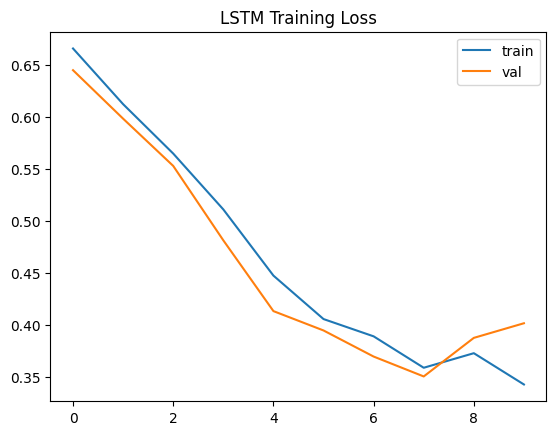

LSTM training complete


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

# Load the prepared sequence data
data = np.load("sequences.npz")
X, y = data["X"], data["y"]

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the LSTM model
model_lstm = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2])),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# Compile and train
model_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

# Plot training progress
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("LSTM Training Loss")
plt.show()

print("LSTM training complete")


In [ ]:
preds = model_lstm.predict(X_val)
preds_bin = (preds > 0.5).astype(int)
accuracy = (preds_bin.flatten() == y_val).mean()
print(f"Validation accuracy: {accuracy*100:.2f}%")

# Simple test visualization
for i in range(5):
    print(f"Seq {i}: True={y_val[i]}, Pred={preds_bin[i][0]} (prob={preds[i][0]:.2f})")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Validation accuracy: 77.52%
Seq 0: True=1, Pred=0 (prob=0.27)
Seq 1: True=1, Pred=0 (prob=0.28)
Seq 2: True=0, Pred=0 (prob=0.02)
Seq 3: True=1, Pred=1 (prob=0.60)
Seq 4: True=1, Pred=1 (prob=0.99)


In [ ]:
model_lstm.save_weights("model_lstm.weights.h5")
print("LSTM weights saved to model_lstm.weights.h5")
model_lstm.load_weights("model_lstm.weights.h5")



LSTM weights saved to model_lstm.weights.h5


In [ ]:
import cv2
import numpy as np
from sklearn.preprocessing import StandardScaler
from IPython.display import HTML
from base64 import b64encode

# Load LSTM model
model_lstm.load_weights("model_lstm.weights.h5")  # or use model_lstm directly if already in memory

# Load video
cap = cv2.VideoCapture(video_path)
out_path = "collision_warning_output.mp4"
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(out_path, fourcc, fps, (w, h))

# Simple buffer for LSTM sequence
T = X.shape[1]
buffer = []

print("Running LSTM-based collision prediction...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Simulate detection data (if not using live YOLO inference)
    # In your full pipeline, replace this with real YOLO detections & tracked object features
    cx, cy, width, height = w//2, h//2, 100, 50
    dx, dy = np.random.randn(), np.random.randn()
    speed = np.sqrt(dx**2 + dy**2)
    feat = np.array([cx, cy, width, height, dx, dy, speed])

    # Normalize with same scale as training
    feat = StandardScaler().fit_transform(feat.reshape(1, -1))
    buffer.append(feat.flatten())
    if len(buffer) > T:
        buffer.pop(0)

    # Run LSTM prediction
    if len(buffer) == T:
        x_seq = np.expand_dims(np.stack(buffer), axis=0)
        risk_prob = model_lstm.predict(x_seq, verbose=0)[0, 0]
        if risk_prob > 0.6:
            cv2.putText(frame, f"⚠️ COLLISION RISK ({risk_prob:.2f})",
                        (50, 80), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 0, 255), 3)
        else:
            cv2.putText(frame, f"SAFE ({risk_prob:.2f})",
                        (50, 80), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 255, 0), 3)

    out.write(frame)

cap.release()
out.release()

print(" Output video saved:", out_path)

# Display video inline (optional)
mp4 = open(out_path, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f"""
<video width=600 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")


In [ ]:
!pip install ultralytics opencv-python-headless


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # lightweight pretrained model

# Input and output video paths
input_video = "istockphoto-2159760544-640_adpp_is.mp4"
output_video = "collision_warning_output.mp4"

# Open video
cap = cv2.VideoCapture(input_video)
fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video, fourcc, fps, (w, h))

# Heuristic parameters
previous_area = None
collision_detected = False
frames_since_warning = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, verbose=False)
    annotated = results[0].plot()

    # Estimate "distance" by bounding box area of closest car
    car_boxes = [box for box, cls in zip(results[0].boxes.xyxy, results[0].boxes.cls) if int(cls) in [2, 3, 5, 7]]
    if car_boxes:
        x1, y1, x2, y2 = car_boxes[0]
        area = (x2 - x1) * (y2 - y1)

        if previous_area is not None:
            growth = (area - previous_area) / (previous_area + 1e-6)
            if growth > 0.25:  # object rapidly getting closer
                collision_detected = True
                frames_since_warning = 20  # display warning for next few frames

        previous_area = area

    # Draw warning text
    if frames_since_warning > 0:
        cv2.putText(annotated, "⚠️ COLLISION WARNING!", (80, 80),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 4)
        frames_since_warning -= 1

    out.write(annotated)

cap.release()
out.release()
print("Collision warning video saved as:", output_video)


Collision warning video saved as: collision_warning_output.mp4


In [ ]:

from google.colab import files
files.download("collision_warning_output.mp4")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>